# Paso 1: Instalar y importar bibliotecas necesarias





In [ ]:
%pip install opendatasets
import opendatasets as od
import os
import matplotlib.pyplot as plt
import cv2
import numpy as np
from tqdm import tqdm
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

  Using cached opendatasets-0.1.22-py3-none-any.whl.metadata (9.2 kB)
  Using cached kaggle-1.7.4.5-py3-none-any.whl.metadata (16 kB)
  Using cached click-8.3.3-py3-none-any.whl.metadata (2.6 kB)
  Using cached bleach-6.3.0-py3-none-any.whl.metadata (31 kB)
  Using cached python_slugify-8.0.4-py2.py3-none-any.whl.metadata (8.5 kB)
  Using cached text_unidecode-1.3-py2.py3-none-any.whl.metadata (2.4 kB)
  Using cached webencodings-0.5.1-py2.py3-none-any.whl.metadata (2.1 kB)
Using cached opendatasets-0.1.22-py3-none-any.whl (15 kB)
Using cached click-8.3.3-py3-none-any.whl (110 kB)
Using cached kaggle-1.7.4.5-py3-none-any.whl (181 kB)
Using cached bleach-6.3.0-py3-none-any.whl (164 kB)
Using cached python_slugify-8.0.4-py2.py3-none-any.whl (10 kB)
Using cached text_unidecode-1.3-py2.py3-none-any.whl (78 kB)
Using cached webencodings-0.5.1-py2.py3-none-any.whl (11 kB)

   ----- ---------------------------------- 1/7 [text-unidecode]
   ----------- ---------------------------- 2/7 [python

# Paso 2: Descargar y explorar el conjunto de datos desde Kaggle


In [9]:
dataset_link = "https://www.kaggle.com/datasets/danielshanbalico/dog-emotion"
od.download(dataset_link)
dataset_dir = "./dog-emotion/Dog Emotion"

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:Your Kaggle username:Your Kaggle username:Your Kaggle Key:Dataset URL: https://www.kaggle.com/datasets/danielshanbalico/dog-emotion


100%|██████████| 155M/155M [00:00<00:00, 709MB/s] 


# Paso 3: Visualizar algunas imágenes del conjunto de datos


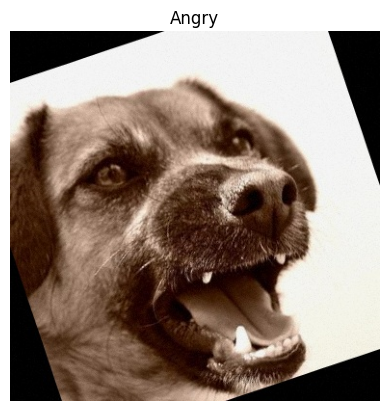

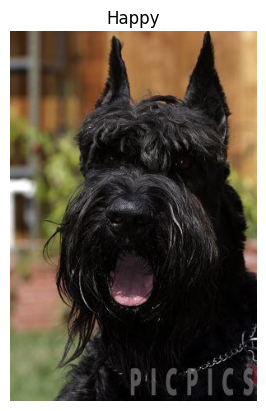

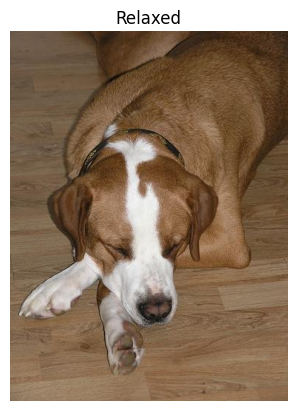

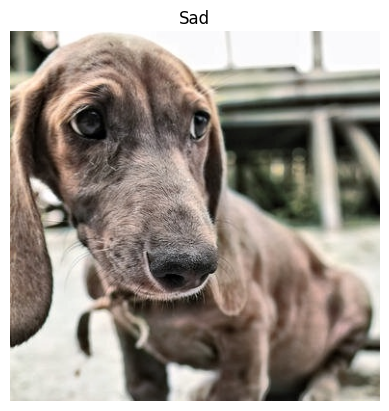

In [10]:
folders = ["angry", "happy", "relaxed", "sad"]

def show_images(folder):
    folder_path = os.path.join(dataset_dir, folder)
    image_file = os.listdir(folder_path)[0]
    image = cv2.imread(os.path.join(folder_path, image_file))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.title(folder.capitalize())
    plt.axis('off')
    plt.show()

for folder in folders:
    show_images(folder)

# Paso 4: Preprocesamiento de datos


In [11]:
def preprocess_image(image_path):
    image = cv2.imread(image_path)
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized_image = cv2.resize(gray_image, (150, 150))
    return resized_image

data_pairs = []

for folder in folders:
    folder_path = os.path.join(dataset_dir, folder)
    image_files = os.listdir(folder_path)
    for image_file in tqdm(image_files, desc=f"Procesando {folder}"):
        image_path = os.path.join(folder_path, image_file)
        processed_image = preprocess_image(image_path)
        data_pairs.append((processed_image, folder))

Procesando sad: 100%|██████████| 1000/1000 [00:13<00:00, 73.65it/s]


# Paso 5: Visualizar imágenes preprocesadas


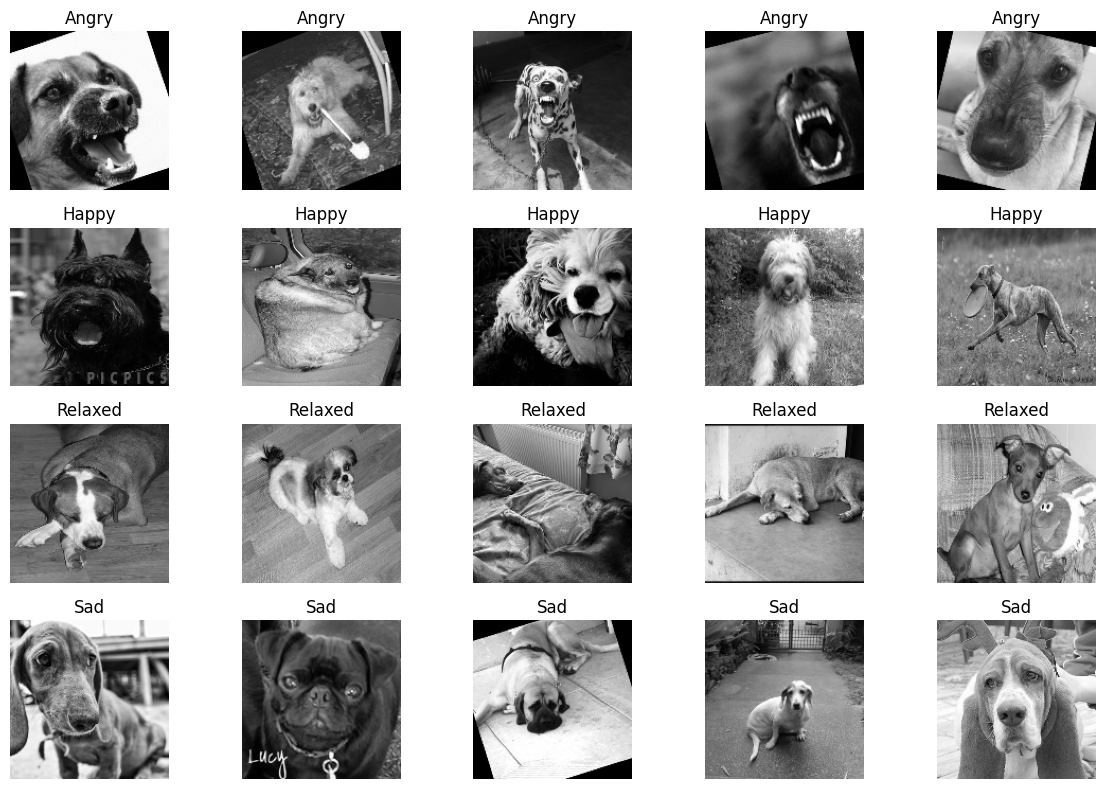

In [12]:
num_images_per_emotion = 5
plt.figure(figsize=(12, 8))
for i, emotion in enumerate(folders):
    emotion_images = [pair[0] for pair in data_pairs if pair[1] == emotion][:num_images_per_emotion]
    for j, image in enumerate(emotion_images):
        plt.subplot(len(folders), num_images_per_emotion, i * num_images_per_emotion + j + 1)
        plt.imshow(image, cmap='gray')
        plt.title(emotion.capitalize())
        plt.axis('off')
plt.tight_layout()
plt.show()

# Paso 6: Preparación de datos para el modelo CNN




In [13]:
X = np.array([pair[0] for pair in data_pairs])
y = np.array([folders.index(pair[1]) for pair in data_pairs])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train / 255.0
X_test = X_test / 255.0
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

# Paso 7: Aumento de datos y creación del modelo CNN


In [14]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

c:\Users\Cesar\Desktop\DogEmotionRecognition-CNN-main\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,292 (18.42 MB)

 Trainable params: 4,828,292 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

# Paso 8: Entrenamiento del modelo


In [15]:
train_datagen.fit(X_train)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=12,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=5,
        min_lr=1e-6
    )
]

history = model.fit(train_datagen.flow(X_train, y_train, batch_size=32),
                    epochs=80,
                    validation_data=(X_test, y_test),
                    callbacks=callbacks)

Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 257ms/step - accuracy: 0.3091 - loss: 1.3455 - val_accuracy: 0.3237 - val_loss: 1.2985
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 247ms/step - accuracy: 0.3394 - loss: 1.2935 - val_accuracy: 0.3313 - val_loss: 1.3043
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 250ms/step - accuracy: 0.3309 - loss: 1.2903 - val_accuracy: 0.3537 - val_loss: 1.2701
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 255ms/step - accuracy: 0.3466 - loss: 1.2913 - val_accuracy: 0.3363 - val_loss: 1.2981
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 249ms/step - accuracy: 0.3422 - loss: 1.2826 - val_accuracy: 0.3738 - val_loss: 1.2541
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 247ms/step - accuracy: 0.3503 - loss: 1.2852 - val_accuracy: 0.3862 - val_loss: 1.2731
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 259ms/step - accuracy: 0.3494 - loss: 1.2786 - val_accuracy: 0.3562 - val_loss: 1.2569
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 260ms/step - accuracy: 0.3484 - loss: 1

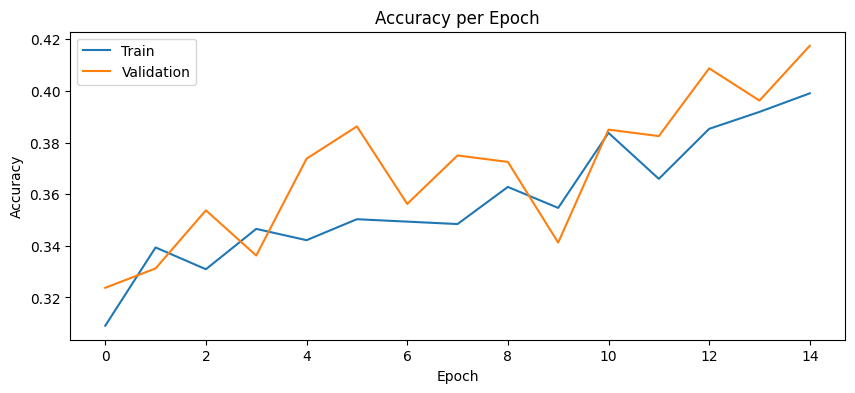

In [16]:
# Visualización de la precisión del modelo por época
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label="Train")
plt.plot(history.history['val_accuracy'], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy per Epoch")
plt.legend()
plt.show()

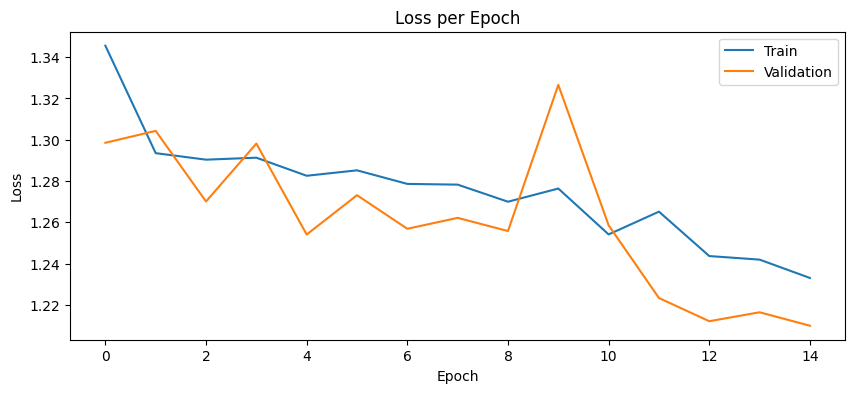

In [17]:
# Visualización de la pérdida del modelo por época
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label="Train")
plt.plot(history.history['val_loss'], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss per Epoch")
plt.legend()
plt.show()

# Paso 9: Calcular y mostrar la precisión del modelo en el conjunto de prueba


In [18]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Precisión en el conjunto de prueba: {test_accuracy}')

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.4175 - loss: 1.2099
Precisión en el conjunto de prueba: 0.41749998927116394


# Paso 10: Evaluación del modelo y visualización de resultados


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


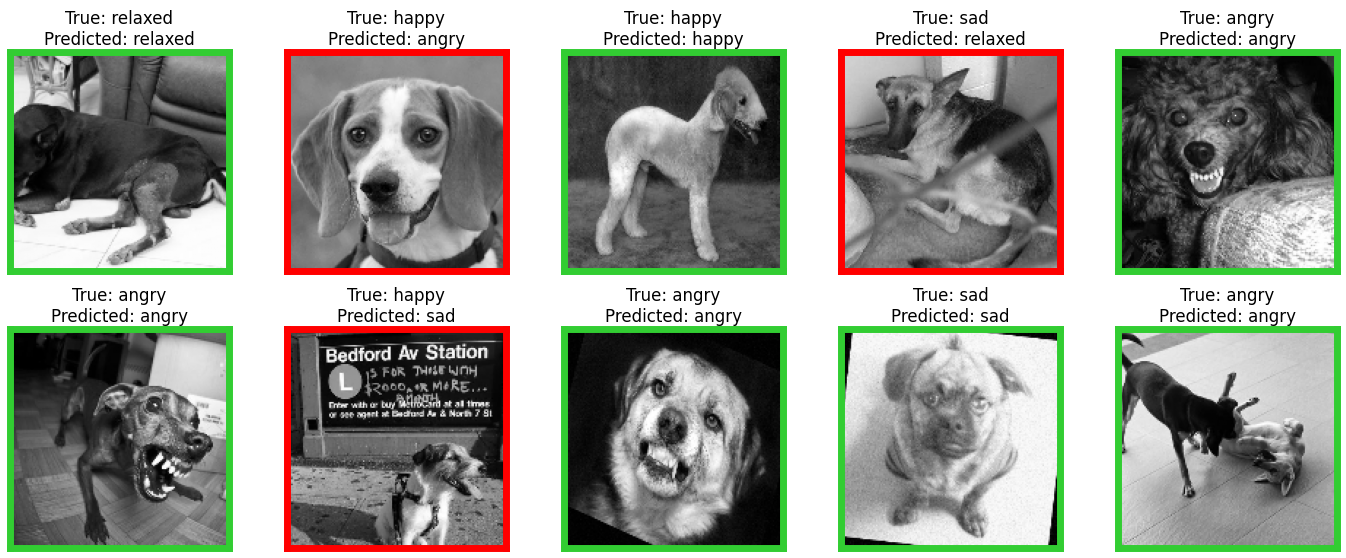

In [19]:
random_indices = np.random.choice(len(X_test), size=10, replace=False)
sample_images = X_test[random_indices]
sample_labels = y_test[random_indices]
predictions = model.predict(sample_images)

emotion_labels = {0: "angry", 1: "happy", 2: "relaxed", 3: "sad"}

def get_border_color(true_emotion, predicted_emotion):
    if true_emotion == predicted_emotion:
        return 'limegreen'
    else:
        return 'red'

plt.figure(figsize=(14, 14))
for i in range(10):
    true_emotion = emotion_labels[sample_labels[i]]
    predicted_emotion = emotion_labels[np.argmax(predictions[i])]
    border_color = get_border_color(true_emotion, predicted_emotion)
    plt.subplot(5, 5, i + 1)
    plt.imshow(sample_images[i].reshape(150, 150), cmap='gray')
    plt.gca().set_xticks([])
    plt.gca().set_yticks([])
    for axis in ['top', 'bottom', 'left', 'right']:
        plt.gca().spines[axis].set_linewidth(5)
        plt.gca().spines[axis].set_color(border_color)
    plt.title(f"True: {true_emotion}\nPredicted: {predicted_emotion}")
plt.tight_layout()
plt.show()

# Paso 11: Realización de predicción en una imagen nueva


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


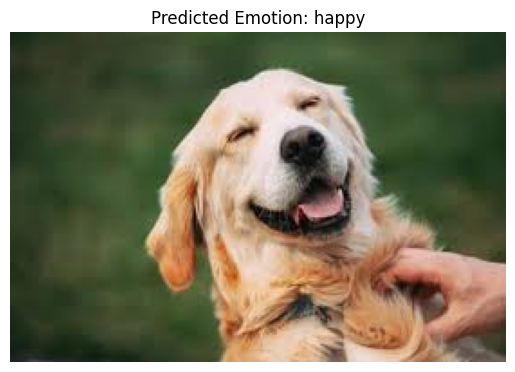

In [21]:
def load_and_preprocess_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (150, 150))
    image = image / 255.0
    image = np.expand_dims(image, axis=-1)
    return image

def predict_emotion(image_path):
    image = load_and_preprocess_image(image_path)
    prediction = model.predict(np.array([image]))
    predicted_emotion = emotion_labels[np.argmax(prediction)]
    image_rgb = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.title(f'Predicted Emotion: {predicted_emotion}')
    plt.show()

predict_emotion("images.jpg")

# Paso 11: Guardar el modelo entrenado

In [22]:
model.save('emotionDog.h5')

In [23]:
!pip install tensorflowjs

^C


In [24]:
!mkdir carpeta_DogEmotion

In [ ]:
!tensorflowjs_converter --input_format keras emotionDog.h5 carpeta_salida

"tensorflowjs_converter" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


  Using cached tensorflow_decision_forests-1.8.1.tar.gz (15.2 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl.metadata (1.3 kB)
INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
  Using cached wheel-0.46.3-py3-none-any.whl.metadata (2.4 kB)
  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
INFO: pip is looking at multiple versions of tensorflow-intel to determine which version is compatible with other requirements. This could take a while.
  Using cached keras-3.12.2-py3-none-any.whl.metadata (5.9 kB)
  Using cached keras-3.12.0-py3-none-any.whl

error: resolution-too-deep

× Dependency resolution exceeded maximum depth
╰─> Pip cannot resolve the current dependencies as the dependency graph is too complex for pip to solve efficiently.

hint: Try adding lower bounds to constrain your dependencies, for example: 'package>=2.0.0' instead of just 'package'.

Link: https://pip.pypa.io/en/stable/topics/dependency-resolution/#handling-resolution-too-deep-errors


: 